# Hogares mexicanos: ingreso y desigualdad por decil (ENIGH 2024 NS)

**Pregunta**: ¿Cómo se distribuye el ingreso de los hogares mexicanos por decil de ingreso?

**Dataset**: ENIGH 2024 Nueva Serie publicada por INEGI. La Nueva Serie introduce ajustes metodológicos respecto a la ENIGH Tradicional, por lo que **no es directamente comparable** con ediciones previas a 2022.

Cada decil agrupa al 10% de los hogares ordenados por ingreso corriente: D1 son los hogares de menor ingreso, D10 los de mayor.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from datos_mexico import DatosMexico

client = DatosMexico()

## 1. KPIs nacionales

In [2]:
summary = client.enigh.hogares_summary()
print(f"Edición: {summary.edition}")
print(f"Hogares en muestra: {summary.n_hogares_muestra:,}")
print(f"Hogares expandidos (universo nacional): {summary.n_hogares_expandido:,}")
print(f"Ingreso corriente medio mensual: ${summary.mean_ing_cor_mensual:,.2f} MXN")
print(f"Gasto monetario medio mensual:   ${summary.mean_gasto_mon_mensual:,.2f} MXN")

Edición: ENIGH 2024 Nueva Serie
Hogares en muestra: 91,414
Hogares expandidos (universo nacional): 38,830,230
Ingreso corriente medio mensual: $25,954.61 MXN
Gasto monetario medio mensual:   $15,891.46 MXN


## 2. Ingreso medio por decil

In [3]:
deciles = client.enigh.hogares_by_decil()
df_dec = pd.DataFrame(
    [
        {
            "decil": d.decil,
            "hogares_expandidos": d.n_hogares_expandido,
            "ingreso_medio_mensual": float(d.mean_ing_cor_mensual),
            "gasto_medio_trim": float(d.mean_gasto_mon_trim),
        }
        for d in deciles
    ]
)
df_dec

,decil,hogares_expandidos,ingreso_medio_mensual,gasto_medio_trim
0,1,3882924,5598.38,16954.72
1,2,3883042,9432.21,23333.68
2,3,3883010,12281.47,28329.32
3,4,3882672,15081.30,32816.93
4,5,3883138,18102.24,37468.31
5,6,3883019,21532.93,43028.49
6,7,3883005,25816.49,48840.44
7,8,3882963,31763.03,57490.69
8,9,3883293,41236.61,70489.70
9,10,3883164,78697.34,117985.63


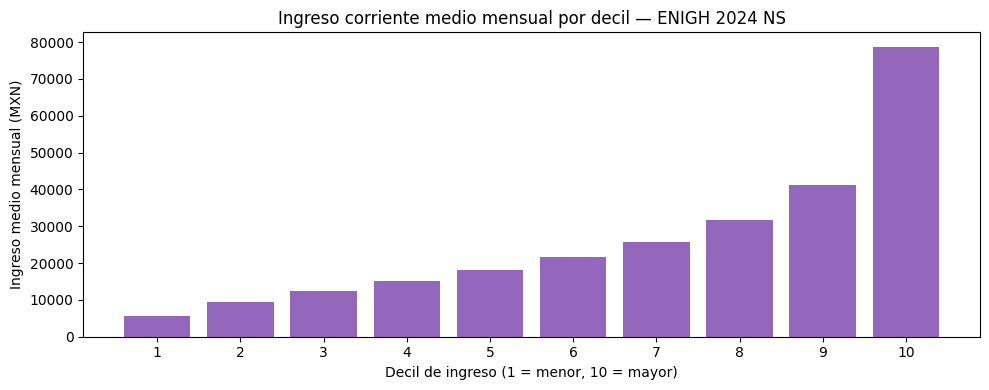

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_dec["decil"], df_dec["ingreso_medio_mensual"], color="#9467bd")
ax.set_title("Ingreso corriente medio mensual por decil — ENIGH 2024 NS")
ax.set_xlabel("Decil de ingreso (1 = menor, 10 = mayor)")
ax.set_ylabel("Ingreso medio mensual (MXN)")
ax.set_xticks(list(range(1, 11)))
fig.tight_layout()
plt.show()

## 3. Razón D10/D1 — un proxy de desigualdad

In [5]:
d1 = next(d for d in deciles if d.decil == 1)
d10 = next(d for d in deciles if d.decil == 10)
ratio = float(d10.mean_ing_cor_mensual) / float(d1.mean_ing_cor_mensual)
print(f"D1 ingreso medio:  ${d1.mean_ing_cor_mensual:,.2f} MXN/mes")
print(f"D10 ingreso medio: ${d10.mean_ing_cor_mensual:,.2f} MXN/mes")
print(f"Razón D10/D1: {ratio:.1f}x")

D1 ingreso medio:  $5,598.38 MXN/mes
D10 ingreso medio: $78,697.34 MXN/mes
Razón D10/D1: 14.1x


## 4. Composición del gasto por rubro (nacional)

In [6]:
rubros = client.enigh.gastos_by_rubro()
df_rubros = pd.DataFrame(
    [
        {
            "rubro": r.nombre,
            "slug": r.slug,
            "mean_mensual": float(r.mean_gasto_mensual),
            "pct_del_monetario": float(r.pct_del_monetario),
        }
        for r in rubros.rubros
    ]
).sort_values("pct_del_monetario", ascending=False)
df_rubros

,rubro,slug,mean_mensual,pct_del_monetario
0,"Alimentos, bebidas y tabaco",alimentos,5994.01,37.72
1,Transporte y comunicaciones,transporte,3106.39,19.55
2,Educación y esparcimiento,educacion_esparcimiento,1530.94,9.63
3,Vivienda y servicios,vivienda,1448.69,9.12
4,Cuidados personales,cuidados_personales,1236.28,7.78
5,Enseres / limpieza del hogar,limpieza_hogar,1004.73,6.32
6,Vestido y calzado,vestido_calzado,609.98,3.84
7,Salud,salud,535.09,3.37
8,Transferencias y otros gastos,transferencias_gasto,425.33,2.68


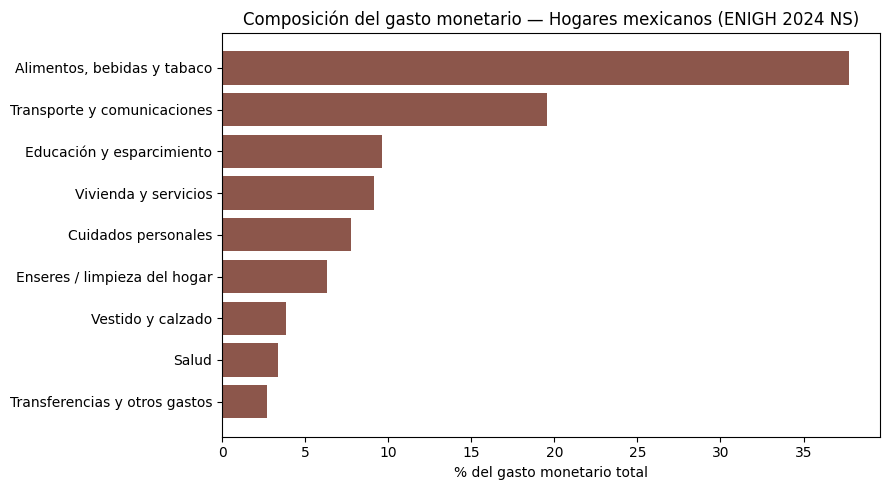

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_rubros["rubro"], df_rubros["pct_del_monetario"], color="#8c564b")
ax.set_title("Composición del gasto monetario — Hogares mexicanos (ENIGH 2024 NS)")
ax.set_xlabel("% del gasto monetario total")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 5. Composición del gasto: D1 vs D10

In [8]:
rubros_d1 = client.enigh.gastos_by_rubro(decil=1)
rubros_d10 = client.enigh.gastos_by_rubro(decil=10)

df_d1 = pd.DataFrame(
    [{"rubro": r.nombre, "d1": float(r.pct_del_monetario)} for r in rubros_d1.rubros]
).set_index("rubro")
df_d10 = pd.DataFrame(
    [{"rubro": r.nombre, "d10": float(r.pct_del_monetario)} for r in rubros_d10.rubros]
).set_index("rubro")
df_compare = df_d1.join(df_d10).sort_values("d1", ascending=False)
df_compare

,d1,d10
rubro,,
"Alimentos, bebidas y tabaco",51.13,28.72
Transporte y comunicaciones,12.75,21.48
Vivienda y servicios,10.37,8.23
Cuidados personales,6.91,8.24
Enseres / limpieza del hogar,6.48,7.53
Educación y esparcimiento,4.16,13.91
Salud,3.84,4.14
Vestido y calzado,2.84,4.15
Transferencias y otros gastos,1.52,3.59


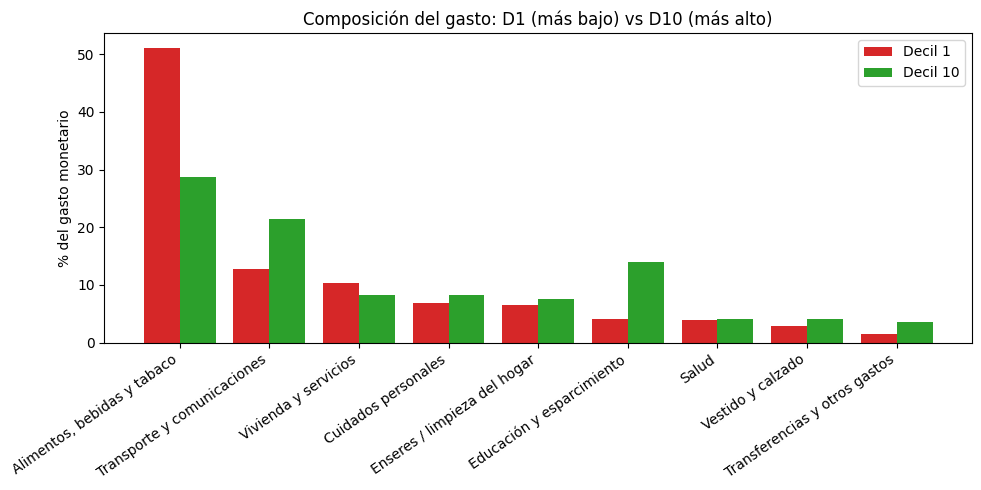

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_compare))
ax.bar([i - 0.2 for i in x], df_compare["d1"], width=0.4, label="Decil 1", color="#d62728")
ax.bar([i + 0.2 for i in x], df_compare["d10"], width=0.4, label="Decil 10", color="#2ca02c")
ax.set_xticks(list(x))
ax.set_xticklabels(df_compare.index, rotation=35, ha="right")
ax.set_ylabel("% del gasto monetario")
ax.set_title("Composición del gasto: D1 (más bajo) vs D10 (más alto)")
ax.legend()
fig.tight_layout()
plt.show()

Los hogares de D1 destinan una proporción mayor de su gasto a necesidades básicas (alimentos, vivienda); los de D10 destinan proporcionalmente más a transporte, educación y servicios. Esto se conoce como **Ley de Engel** y es consistente con la literatura.

## 6. Validaciones contra cifras INEGI

El observatorio publica un endpoint de validaciones que confronta sus cifras calculadas con las publicadas oficialmente por INEGI. Esto es una garantía de calidad de los datos: si todas pasan, los cálculos del observatorio están alineados con los oficiales.

In [10]:
val = client.enigh.validaciones()
print(f"Bounds totales: {val.count}")
print(f"Passing:       {val.passing}")
print(f"Failing:       {val.failing}")
df_val = pd.DataFrame(
    [
        {
            "id": b.id,
            "scope": b.scope,
            "metric": b.metric,
            "calculado": float(b.calculado),
            "oficial": float(b.oficial),
            "delta_pct": float(b.delta_pct),
            "passing": b.passing,
        }
        for b in val.bounds
    ]
)
df_val

Bounds totales: 13
Passing:       13
Failing:       0


,id,scope,metric,calculado,oficial,delta_pct,passing
0,ingreso_total,total,Ingreso corriente promedio por hogar (total),77863.84,77864.0,-0.0002,True
1,ingreso_d1,d1,Ingreso corriente promedio — decil I,16795.15,16795.0,0.0009,True
2,ingreso_d10,d10,Ingreso corriente promedio — decil X,236092.03,236095.0,-0.0013,True
3,gasto_gasto_monetario,mensual,Gasto monetario total,15891.46,15891.0,0.0029,True
4,gasto_alimentos,mensual,"Alimentos, bebidas y tabaco",5994.01,5994.0,0.0002,True
5,gasto_transporte,mensual,Transporte y comunicaciones,3106.39,3106.0,0.0126,True
6,gasto_educacion_esparcimiento,mensual,Educación y esparcimiento,1530.94,1531.0,-0.0039,True
7,gasto_vivienda,mensual,Vivienda y servicios,1448.69,1449.0,-0.0215,True
8,gasto_cuidados_personales,mensual,Cuidados personales,1236.28,1236.0,0.0230,True
9,gasto_limpieza_hogar,mensual,Enseres / limpieza del hogar,1004.73,1005.0,-0.0264,True


## Lo que estos datos NO muestran

- **Sub-reporte del extremo alto**: como toda encuesta, ENIGH típicamente sub-reporta hogares de muy alto patrimonio. La razón real D10/D1 es probablemente mayor a la observada.
- **Encuesta transversal**: ENIGH es un corte temporal, no sigue hogares a lo largo del tiempo. No permite analizar movilidad intergeneracional ni transiciones entre deciles.
- **Variación intra-decil**: cada decil es un grupo amplio y la varianza dentro de cada uno puede ser grande, especialmente en D10.
- **No comparable con pre-2022**: la Nueva Serie usa metodología actualizada. Comparaciones con ENIGH 2018 o anteriores requieren ajustes que el observatorio no realiza automáticamente.

In [11]:
client.close()